# MOS model: ECMWF forecast + linear correction

**Model Output Statistics (MOS)**: a linear regression that corrects a weather model's raw forecast for this specific station, using the station's own recent observations for the first hours.

- Weather model input: ECMWF IFS HRES 12 UTC runs (from `fetch_ifs_runs.py`), one run per forecast.
- ECMWF's recent bias (last 7 and 30 days) is an input, because its bias at RDU shifted in mid-2025.
- For a forecast issued at local midnight, the run used is the **12 UTC run of the previous day** (8am EDT, published mid-afternoon), so it is fully available before the forecast is issued.
- Archived runs reach 263 h after initialisation (runs before mid-July 2024 stop at 240 h), i.e. through ~day 11 of the forecast. Later hours fall back to the station-only linear model (climatology + decaying anomaly).

Run `python fetch_ifs_runs.py` first.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

TZ = "America/New_York"
HORIZON = 14 * 24
CUTOFF = pd.Timestamp("2026-09-17 00:00", tz=TZ)
RUN_HOUR_UTC = 12             # which daily run to use
MIN_RUN_AGE = pd.Timedelta(hours=12)   # run must start >= 12 h before the forecast is issued

## 2. Observations

In [2]:
raw = pd.read_csv("cleaned_data/rdu_51_clean.csv")
raw["hour"] = pd.to_datetime(raw["DATE"], utc=True).dt.floor("h")
raw = raw.drop_duplicates("hour").set_index("hour").sort_index()

grid = pd.date_range(raw.index.min(), raw.index.max(), freq="h")
obs = raw.reindex(grid)["temperature"]
obs = obs.loc[obs.index < CUTOFF]
temp_local = pd.Series(obs.values, index=obs.index.tz_convert(TZ))
print("Observed hours:", obs.notna().sum(), "| last:", temp_local.index.max())

Observed hours: 49881 | last: 2026-09-16 23:00:00-04:00


## 3. ECMWF runs

In [3]:
nwp = pd.read_csv("nwp_data/ifs_12z_rdu.csv", parse_dates=["init_utc", "valid_utc"])
nwp = nwp[nwp["init_utc"].dt.hour == RUN_HOUR_UTC]
assert nwp["init_utc"].max() <= CUTOFF - MIN_RUN_AGE, "a run newer than the cutoff allows is in the file"

# Fast lookup: forecast temperature by (run, valid hour)
nwp_temp = nwp.set_index(["init_utc", "valid_utc"])["nwp_temp"].sort_index()
available_runs = pd.DatetimeIndex(nwp["init_utc"].unique()).sort_values()

print("Runs:", len(available_runs), "|", available_runs.min(), "->", available_runs.max())
print("Max lead per run (h):", nwp.groupby("init_utc")["lead_h"].max().median())

Runs: 911 | 2024-03-15 12:00:00+00:00 -> 2026-09-16 12:00:00+00:00
Max lead per run (h): 263.0


In [4]:
def run_for(origin):
    """Latest 12 UTC run that started at least MIN_RUN_AGE before the forecast origin."""
    latest_ok = origin.tz_convert("UTC") - MIN_RUN_AGE
    run = latest_ok.normalize() + pd.Timedelta(hours=RUN_HOUR_UTC)
    if run > latest_ok:
        run -= pd.Timedelta(days=1)
    return run if run in available_runs else None


def nwp_path(origin, offsets):
    """ECMWF temperature from the run for `origin`, at origin + offsets (hours). NaN where not covered."""
    run = run_for(origin)
    times = origin.tz_convert("UTC") + pd.to_timedelta(offsets, unit="h")
    if run is None:
        return np.full(len(offsets), np.nan)
    return nwp_temp.reindex(pd.MultiIndex.from_arrays([np.repeat(run, len(times)), times])).values


# Sanity check: raw ECMWF error by lead day for the 2025 season (no model fitting involved)
check = []
for o in pd.date_range("2025-08-15", "2025-10-15", freq="3D", tz=TZ):
    err = nwp_path(o, np.arange(HORIZON)) - temp_local.reindex(pd.date_range(o, periods=HORIZON, freq="h", tz=TZ)).values
    check.append(np.abs(err))
check = np.array(check)
print("Raw ECMWF MAE by lead day (2025 season, days the run covers):")
print(pd.Series(np.nanmean(check.reshape(len(check), 14, 24)[:, :11], axis=(0, 2)), index=range(1, 12)).round(2).to_string())

Raw ECMWF MAE by lead day (2025 season, days the run covers):
1     1.30
2     1.21
3     1.63
4     1.71
5     1.83
6     2.25
7     2.37
8     2.57
9     2.86
10    3.77
11    4.47


### ECMWF bias drifts over time

Mean error (ECMWF − observed) for the first 3 days of each run, by month. The jump around Aug 2025 means a fixed bias correction learned on older runs would over-correct newer ones, so the model gets the *recent* bias as a feature instead.

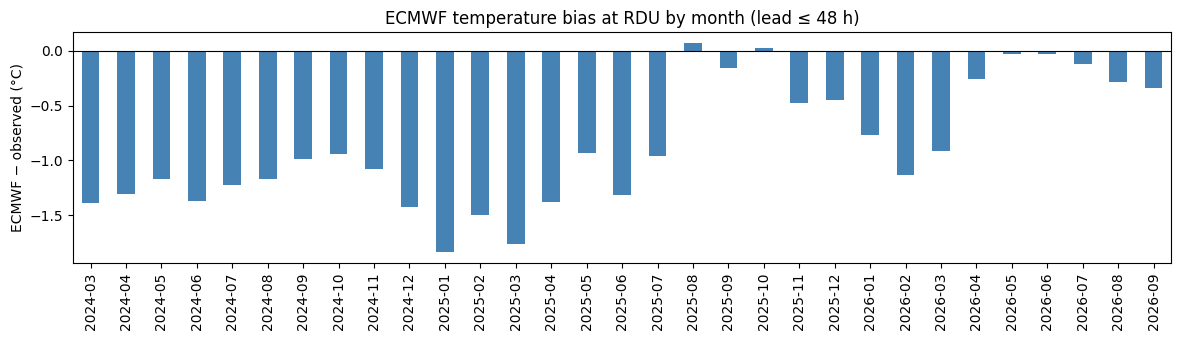

In [5]:
short = nwp[nwp["lead_h"] <= 48].copy()
short["err"] = short["nwp_temp"].values - obs.reindex(short["valid_utc"]).values

monthly = short.groupby(short["valid_utc"].dt.tz_convert(TZ).dt.strftime("%Y-%m"))["err"].mean()
ax = monthly.plot(kind="bar", figsize=(12, 3.5), color="steelblue")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("ECMWF − observed (°C)"); ax.set_xlabel("")
ax.set_title("ECMWF temperature bias at RDU by month (lead ≤ 48 h)")
plt.tight_layout(); plt.show()

# Recent bias known at any hour: average error over the hours already observed.
# Every run contributing to an hour started before that hour, so nothing here is from the future.
err_by_hour = short.groupby("valid_utc")["err"].mean().reindex(obs.index)
RECENT_BIAS = pd.DataFrame({
    "bias_7d": err_by_hour.rolling(168, min_periods=48).mean(),
    "bias_30d": err_by_hour.rolling(720, min_periods=168).mean(),
})

### Adaptive bias

ECMWF's bias at RDU is not constant: about −1.1 °C until July 2025, then near 0 (likely a change in the archived model data). A fixed correction learned from the old period overcorrects later. So the model also gets ECMWF's **recent** average error (last 7 and 30 days), computed only from hours already observed before the forecast is issued.

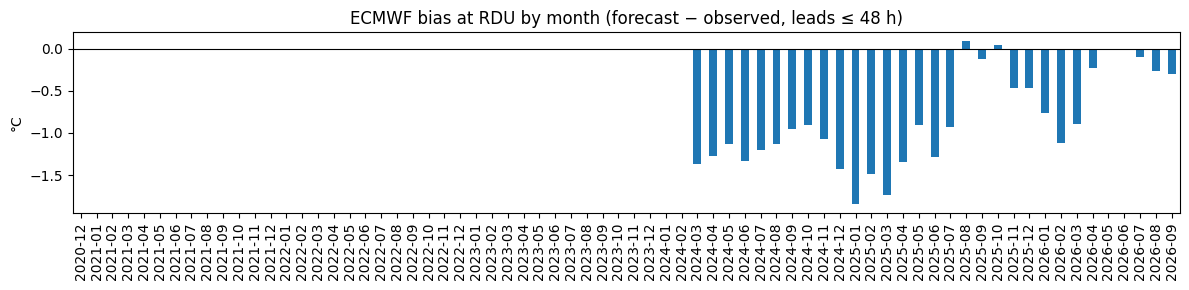

In [6]:
short = nwp[nwp["lead_h"] <= 48].copy()
short["err"] = short["nwp_temp"].values - obs.reindex(short["valid_utc"]).values
err_by_hour = short.groupby("valid_utc")["err"].mean().reindex(obs.index)

RECENT_BIAS = pd.DataFrame({
    "bias_7d": err_by_hour.rolling(168, min_periods=48).mean(),
    "bias_30d": err_by_hour.rolling(720, min_periods=168).mean(),
})

monthly = err_by_hour.groupby(err_by_hour.index.tz_convert(TZ).strftime("%Y-%m")).mean()
ax = monthly.plot(kind="bar", figsize=(12, 3))
ax.set_title("ECMWF bias at RDU by month (forecast − observed, leads ≤ 48 h)")
ax.set_ylabel("°C"); ax.axhline(0, color="black", lw=0.8)
plt.tight_layout(); plt.show()

## 4. Climatology (same as the linear model)

In [7]:
def clim_basis(ts_utc, k_doy=3, k_hr=3):
    t = ts_utc.tz_convert(TZ)
    doy = 2 * np.pi * (t.dayofyear.values - 1) / 365.25
    hr = 2 * np.pi * t.hour.values / 24
    d = [np.ones(len(t))] + [f(k * doy) for k in range(1, k_doy + 1) for f in (np.sin, np.cos)]
    h = [np.ones(len(t))] + [f(k * hr) for k in range(1, k_hr + 1) for f in (np.sin, np.cos)]
    return np.column_stack([a * b for a in d for b in h])[:, 1:]


class Climatology:
    def fit(self, end):
        y = obs.loc[obs.index < end].dropna()
        self.model = LinearRegression().fit(clim_basis(y.index), y.values)
        return self

    def predict(self, ts_utc):
        return self.model.predict(clim_basis(ts_utc))

## 5. Features

Everything is expressed as an anomaly from climatology, so the regression only has to learn corrections.

In [8]:
LEAD = np.arange(HORIZON)
STATION_TAUS = [3, 12, 48]


def station_features(anom):
    """Recent observed anomaly at several windows, read at the hour before each origin."""
    return pd.DataFrame({
        "t_last": anom.ffill(limit=3),
        "t_6h": anom.rolling(6, min_periods=3).mean(),
        "t_24h": anom.rolling(24, min_periods=12).mean(),
        "t_72h": anom.rolling(72, min_periods=36).mean(),
    })


def target_hours(origins):
    return np.array([pd.date_range(o, periods=HORIZON, freq="h", tz=TZ).hour.values for o in origins])


def mos_design(origins, clim, st_feats):
    """Rows = (origin, lead hour). Returns X, NWP-available mask, and names."""
    n = len(origins)
    hours_utc = [o.tz_convert("UTC") + pd.to_timedelta(LEAD, unit="h") for o in origins]
    clim_vals = np.array([clim.predict(h) for h in hours_utc])                     # (n, 336)
    nwp_vals = np.array([nwp_path(o, LEAD) for o in origins])                      # (n, 336)
    nwp_anom = nwp_vals - clim_vals

    # Current ECMWF error: observed minus forecast at the hour before the origin
    obs_prev = obs.reindex([o.tz_convert("UTC") - pd.Timedelta(hours=1) for o in origins]).values
    nwp_prev = np.array([nwp_path(o, [-1])[0] for o in origins])
    err_now = np.nan_to_num(obs_prev - nwp_prev)

    F = st_feats.reindex([o.tz_convert("UTC") - pd.Timedelta(hours=1) for o in origins]).fillna(0).values
    hr = 2 * np.pi * target_hours(origins) / 24
    lead_day = np.broadcast_to(LEAD // 24, (n, HORIZON))

    cols, names = [], []
    for d in range(14):                                          # trust in ECMWF, by lead day
        cols.append(nwp_anom * (lead_day == d)); names.append(f"nwp_anom x day{d + 1}")
    for k in (1, 2):                                             # ECMWF diurnal-cycle correction
        for f, fn in ((np.sin, "sin"), (np.cos, "cos")):
            cols.append(nwp_anom * f(k * hr)); names.append(f"nwp_anom x hour{k}{fn}")
            cols.append(f(k * hr)); names.append(f"hour{k}{fn} (bias)")
    for tau in (6, 24):                                          # current ECMWF error, fading
        cols.append(err_now[:, None] * np.exp(-LEAD / tau)[None, :]); names.append(f"err_now x exp(-L/{tau}h)")
    B = RECENT_BIAS.reindex([o.tz_convert("UTC") - pd.Timedelta(hours=1) for o in origins]).fillna(0).values
    for j, c in enumerate(RECENT_BIAS.columns):                 # ECMWF's recent bias
        cols.append(B[:, j:j + 1]); names.append(c)
    for j, c in enumerate(st_feats.columns):                    # latest observations, fading
        for tau in STATION_TAUS:
            cols.append(F[:, j:j + 1] * np.exp(-LEAD / tau)[None, :]); names.append(f"{c} x exp(-L/{tau}h)")

    X = np.stack([np.broadcast_to(c, (n, HORIZON)) for c in cols], axis=-1).reshape(n * HORIZON, -1)
    has_nwp = ~np.isnan(nwp_anom).ravel()
    X = np.nan_to_num(X)
    return X, has_nwp, clim_vals.ravel(), names

## 6. Models

`StationLinear` is the station-only linear model (fallback beyond the ECMWF horizon). `MOS` uses ECMWF where it is available and the fallback elsewhere.

In [9]:
def daily_origins(first, end):
    """Local-midnight origins whose 336 target hours all end before `end`."""
    last = (end.tz_convert("UTC") - pd.Timedelta(hours=HORIZON)).tz_convert(TZ)
    return pd.date_range(first.tz_convert(TZ).normalize(), last, freq="D", tz=TZ)


def targets(origins, anom):
    t = pd.DatetimeIndex(np.concatenate([o.tz_convert("UTC") + pd.to_timedelta(LEAD, unit="h") for o in origins]))
    return anom.reindex(t).values, t


class StationLinear:
    """Climatology + ridge on recent observed anomalies x lead-time decay."""
    TAUS = [3, 12, 48, 168]

    def fit(self, end, clim, anom):
        self.clim, self.feats = clim, station_features(anom).assign(t_7d=anom.rolling(168, min_periods=84).mean())
        origins = daily_origins(obs.index.min() + pd.Timedelta(days=8), end)
        y, t = targets(origins, anom)
        ok = ~np.isnan(y) & (t < end)
        self.model = make_pipeline(StandardScaler(), Ridge(1.0)).fit(self._X(origins)[ok], y[ok])
        return self

    def _X(self, origins):
        F = self.feats.reindex([o.tz_convert("UTC") - pd.Timedelta(hours=1) for o in origins]).fillna(0).values
        dec = np.column_stack([np.exp(-LEAD / t) for t in self.TAUS])
        return np.einsum("ok,lm->olkm", F, dec).reshape(len(origins) * HORIZON, -1)

    def predict(self, origin):
        hours = origin.tz_convert("UTC") + pd.to_timedelta(LEAD, unit="h")
        return self.clim.predict(hours) + self.model.predict(self._X([origin]))


class MOS:
    def fit(self, end):
        end = end.tz_convert("UTC")
        self.clim = Climatology().fit(end)
        anom = obs - self.clim.predict(obs.index)
        self.st_feats = station_features(anom)
        self.fallback = StationLinear().fit(end, self.clim, anom)

        origins = [o for o in daily_origins(available_runs.min() + pd.Timedelta(days=1), end) if run_for(o) is not None]
        X, has_nwp, _, self.names = mos_design(origins, self.clim, self.st_feats)
        y, t = targets(origins, anom)
        ok = has_nwp & ~np.isnan(y) & (t < end)          # never train on hours at/after `end`
        self.model = make_pipeline(StandardScaler(), Ridge(1.0)).fit(X[ok], y[ok])
        self.n_train, self.n_runs = int(ok.sum()), len(origins)
        return self

    def predict(self, origin):
        X, has_nwp, clim_vals, _ = mos_design([origin], self.clim, self.st_feats)
        pred = self.fallback.predict(origin)
        pred[has_nwp] = clim_vals[has_nwp] + self.model.predict(X[has_nwp])
        return pred

    def raw_nwp(self, origin):
        """Uncorrected ECMWF, climatology where the run does not reach."""
        raw = nwp_path(origin, LEAD)
        clim = self.clim.predict(origin.tz_convert("UTC") + pd.to_timedelta(LEAD, unit="h"))
        return np.where(np.isnan(raw), clim, raw)

## 7. Backtest

Same protocol as the linear notebook (origins every 3 days, Aug 15 – Oct 15), but only 2024 and 2025 have archived ECMWF runs. For each season the model is retrained on data before the season's first origin; the 2024 model therefore has only ~5 months of ECMWF history to learn from.

In [10]:
def score(pred, origin, name, rows):
    actual = temp_local.reindex(pd.date_range(origin, periods=HORIZON, freq="h", tz=TZ)).values
    err = pred - actual
    for d in range(14):
        e = err[d * 24:(d + 1) * 24]
        e = e[~np.isnan(e)]
        rows.append({"origin": origin, "model": name, "lead_day": d + 1,
                     "abs_err": np.abs(e).sum(), "sq_err": (e ** 2).sum(), "n": len(e)})


rows = []
for year in [2024, 2025]:
    origins = pd.date_range(f"{year}-08-15", f"{year}-10-15", freq="3D", tz=TZ)
    m = MOS().fit(origins[0])
    print(f"{year}: trained on {m.n_runs} ECMWF runs, {m.n_train:,} rows")
    for o in origins:
        assert run_for(o) <= o.tz_convert("UTC") - MIN_RUN_AGE
        hours = o.tz_convert("UTC") + pd.to_timedelta(LEAD, unit="h")
        score(m.predict(o), o, "MOS (ECMWF + station)", rows)
        score(m.raw_nwp(o), o, "raw ECMWF", rows)
        score(m.fallback.predict(o), o, "station-only linear", rows)
        score(m.clim.predict(hours), o, "climatology", rows)

results = pd.DataFrame(rows)


def summarize(res, days=range(1, 15)):
    r = res[res.lead_day.isin(days)]
    per = r.groupby(["model", "origin"])[["abs_err", "sq_err", "n"]].sum()
    per = pd.DataFrame({"MAE": per.abs_err / per.n, "RMSE": np.sqrt(per.sq_err / per.n)})
    return per.groupby("model").agg(["mean", "std"]).round(2).sort_values(("MAE", "mean"))


print("All 14 days")
display(summarize(results))
print("Days 1-9 (ECMWF coverage)")
display(summarize(results, range(1, 10)))

2024: trained on 139 ECMWF runs, 31,643 rows


2025: trained on 504 ECMWF runs, 121,910 rows
All 14 days


MAE        RMSE      
                       mean   std  mean   std
model                                        
MOS (ECMWF + station)  2.24  0.40  2.84  0.47
raw ECMWF              2.39  0.48  3.01  0.59
station-only linear    2.91  0.43  3.47  0.46
climatology            3.03  0.39  3.57  0.41

Days 1-9 (ECMWF coverage)


MAE        RMSE      
                       mean   std  mean   std
model                                        
MOS (ECMWF + station)  1.80  0.46  2.30  0.56
raw ECMWF              2.00  0.54  2.52  0.64
station-only linear    2.81  0.57  3.37  0.63
climatology            3.01  0.57  3.54  0.62

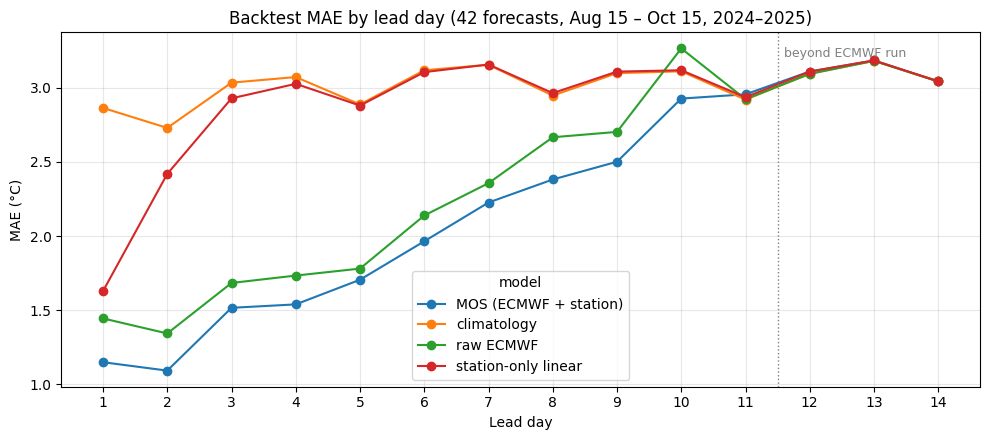

model,MOS (ECMWF + station),climatology,raw ECMWF,station-only linear
lead_day,,,,
1,1.15,2.86,1.45,1.63
2,1.09,2.73,1.34,2.42
3,1.52,3.03,1.68,2.93
4,1.54,3.07,1.73,3.03
5,1.71,2.89,1.78,2.88
6,1.97,3.12,2.14,3.11
7,2.23,3.16,2.36,3.16
8,2.38,2.95,2.67,2.96
9,2.50,3.10,2.70,3.11


In [11]:
by_day = results.groupby(["model", "lead_day"])[["abs_err", "n"]].sum()
by_day = (by_day.abs_err / by_day.n).unstack(0)

ax = by_day.plot(figsize=(10, 4.5), marker="o")
ax.axvline(11.5, color="grey", ls=":", lw=1)
ax.text(11.6, ax.get_ylim()[1] * 0.97, "beyond ECMWF run", va="top", fontsize=9, color="grey")
ax.set_xlabel("Lead day"); ax.set_ylabel("MAE (°C)"); ax.set_xticks(range(1, 15))
ax.set_title("Backtest MAE by lead day (42 forecasts, Aug 15 – Oct 15, 2024–2025)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
by_day.round(2)

## 8. Largest MOS coefficients (standardized features)

In [12]:
coefs = pd.Series(m.model[-1].coef_, index=m.names)
coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15).round(3)

nwp_anom x day1         1.278
nwp_anom x day2         1.273
nwp_anom x day3         1.237
nwp_anom x day4         1.203
nwp_anom x day5         1.169
nwp_anom x day6         1.091
nwp_anom x day7         1.007
nwp_anom x day8         0.890
nwp_anom x day9         0.837
t_6h x exp(-L/12h)      0.823
nwp_anom x day10        0.665
t_72h x exp(-L/12h)     0.523
t_last x exp(-L/12h)   -0.522
t_24h x exp(-L/12h)    -0.519
t_72h x exp(-L/48h)    -0.513
dtype: float64

## 9. Final forecast: Sep 17–30, 2026

Uses the 2026-09-16 12 UTC run (8am EDT, published mid-afternoon Sep 16). The model is retrained on everything before the cutoff.

ECMWF run used: 2026-09-16 12:00:00+00:00 = 2026-09-16 08:00:00-04:00


Hours covered by ECMWF: 248 / 336 (through 2026-09-27 07:00:00-04:00)
Saved: rdu_mos_predictions.csv


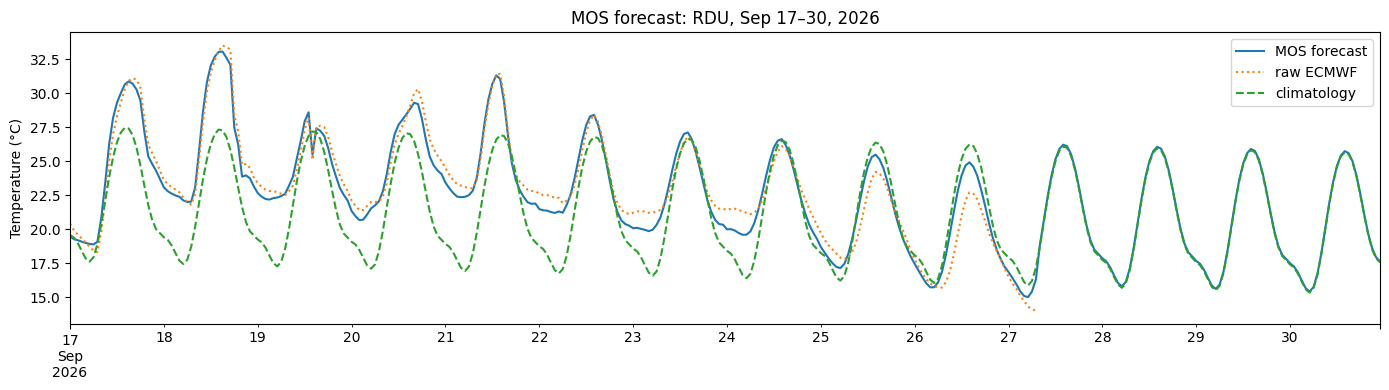

In [13]:
run = run_for(CUTOFF)
print("ECMWF run used:", run, "=", run.tz_convert(TZ))
assert run <= CUTOFF.tz_convert("UTC") - MIN_RUN_AGE

final = MOS().fit(CUTOFF)
hours = pd.date_range(CUTOFF, periods=HORIZON, freq="h", tz=TZ)
forecast = pd.DataFrame({"hour_local": hours, "predicted_temperature": final.predict(CUTOFF)})
forecast.to_csv("rdu_mos_predictions.csv", index=False)

covered = ~np.isnan(nwp_path(CUTOFF, LEAD))
print(f"Hours covered by ECMWF: {covered.sum()} / {HORIZON} (through {hours[covered][-1]})")
print("Saved: rdu_mos_predictions.csv")

plot_df = pd.DataFrame({
    "MOS forecast": forecast["predicted_temperature"].values,
    "raw ECMWF": nwp_path(CUTOFF, LEAD),
    "climatology": final.clim.predict(hours.tz_convert("UTC")),
}, index=hours)
ax = plot_df.plot(figsize=(14, 4), style={"climatology": "--", "raw ECMWF": ":"})
ax.set_title("MOS forecast: RDU, Sep 17–30, 2026"); ax.set_ylabel("Temperature (°C)")
plt.tight_layout(); plt.show()